## 1. Data Collection (Simulasi Rekam Medis)
Karena kita tidak menggunakan data pasien asli, kita akan membuat data simulasi menggunakan Pandas yang menggabungkan data numerik (tanda-tanda vital) dan data teks (keluhan pasien).

In [3]:
import pandas as pd
import numpy as np

# Simulasi data rekam medis pasien
data_pasien = {
    'keluhan_utama': [
        'Demam tinggi sudah 3 hari disertai batuk kering',
        'Nyeri dada sebelah kiri menjalar ke lengan',
        'Pusing, mual, dan lemas setelah beraktivitas',
        'Nyeri perut hebat di bagian bawah kanan',
        'Gatal-gatal merah di seluruh area punggung',
        None # Data kosong untuk simulasi cleaning
    ],
    'suhu_tubuh': [38.5, 36.6, 37.0, 38.2, 36.5, 37.5],
    'tekanan_darah_sistolik': [120, 150, 90, 110, 120, np.nan],
    'diagnosis': ['Flu/Infeksi Saluran Napas', 'Gangguan Jantung', 'Hipotensi', 'Apendisitis', 'Alergi Kulit', 'Flu'],
    'saran_terapi': ['Istirahat & Parasetamol', 'Rujuk Spesialis Jantung', 'Minum cukup & Glukosa', 'Rujuk Bedah', 'Antihistamin', 'Istirahat']
}

df_pasien = pd.DataFrame(data_pasien)
df_pasien.to_csv('patient_records.csv', index=False)

## 2. Data Manipulation (NumPy & Pandas)
Data medis sering kali memiliki nilai yang hilang. Kita akan menggunakan Pandas untuk membersihkannya dan NumPy untuk menormalkan data angka agar model lebih stabil.

In [4]:
# 1. Memuat data
df = pd.read_csv('patient_records.csv')

# 2. Menangani nilai yang hilang (Imputation)
# Mengisi tekanan darah yang kosong dengan nilai rata-rata (NumPy)
mean_td = df['tekanan_darah_sistolik'].mean()
df['tekanan_darah_sistolik'] = df['tekanan_darah_sistolik'].fillna(mean_td)

# Menghapus baris yang keluhan utamanya kosong
df = df.dropna(subset=['keluhan_utama'])

# 3. Normalisasi dengan NumPy
# Mengubah suhu tubuh ke skala 0-1 agar seragam
suhu_min = np.min(df['suhu_tubuh'])
suhu_max = np.max(df['suhu_tubuh'])
df['suhu_normalized'] = (df['suhu_tubuh'] - suhu_min) / (suhu_max - suhu_min)

print("Data Setelah Dimanipulasi:")
print(df[['keluhan_utama', 'suhu_normalized', 'diagnosis']].head())

Data Setelah Dimanipulasi:
                                     keluhan_utama  suhu_normalized  \
0  Demam tinggi sudah 3 hari disertai batuk kering             1.00   
1       Nyeri dada sebelah kiri menjalar ke lengan             0.05   
2     Pusing, mual, dan lemas setelah beraktivitas             0.25   
3          Nyeri perut hebat di bagian bawah kanan             0.85   
4       Gatal-gatal merah di seluruh area punggung             0.00   

                   diagnosis  
0  Flu/Infeksi Saluran Napas  
1           Gangguan Jantung  
2                  Hipotensi  
3                Apendisitis  
4               Alergi Kulit  


## 3. Exploratory Data Analysis (Matplotlib & Seaborn)
Pada tahap ini, kita akan menggunakan visualisasi untuk melihat bagaimana tanda-tanda vital (seperti suhu tubuh) berhubungan dengan diagnosis penyakit pasien.


> Heatmap Korelasi: Kita akan membuat matriks visual untuk melihat gejala atau tanda vital mana yang paling kuat menentukan suatu diagnosis penyakit.


> Analisis Distribusi: Kita akan mengecek apakah jumlah data untuk setiap jenis penyakit seimbang, agar model tidak hanya "pintar" menebak penyakit yang datanya paling banyak saja.

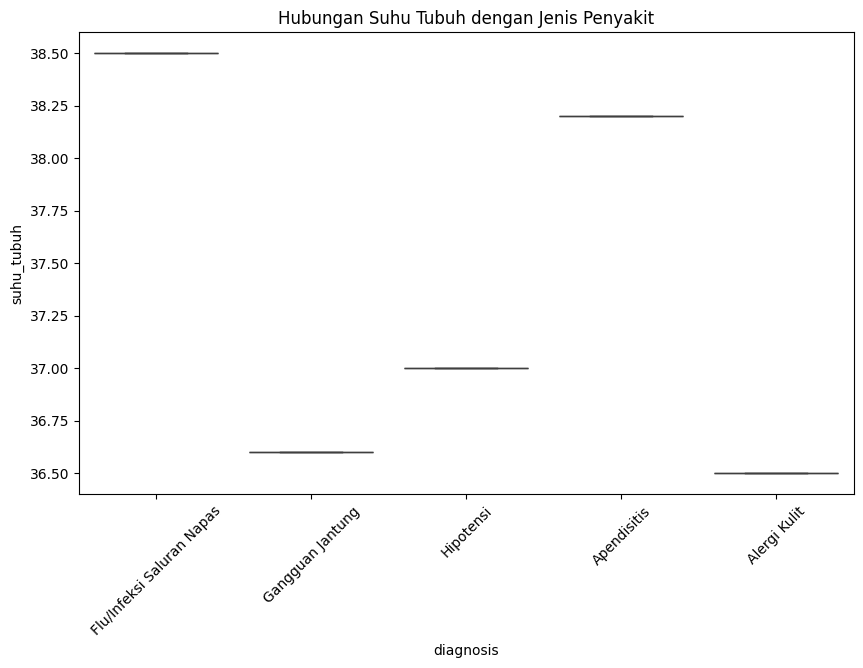

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi hubungan antara Suhu Tubuh dan Diagnosis
plt.figure(figsize=(10, 6))
sns.boxplot(x='diagnosis', y='suhu_tubuh', data=df)
plt.title('Hubungan Suhu Tubuh dengan Jenis Penyakit')
plt.xticks(rotation=45)
plt.show()

# Insight: Pasien dengan diagnosis 'Flu' cenderung memiliki rata-rata suhu tubuh lebih tinggi.

## 4. NLP Preprocessing (Keluhan Pasien)
Setelah memahami pola datanya, kita harus mengolah teks "keluhan utama" pasien agar bisa "dimengerti" oleh algoritma. Komputer tidak bisa membaca kalimat secara langsung, jadi kita harus menyederhanakannya melalui beberapa langkah:
* Lowercasing: Mengubah semua kata menjadi huruf kecil.
* Cleaning: Menghapus karakter yang tidak perlu (seperti tanda baca atau angka).
* Stopword Removal: Menghapus kata-kata umum dalam bahasa Indonesia yang tidak memiliki makna medis spesifik (seperti "dan", "di", "sudah").

In [6]:
import re

def preprocess_keluhan(text):
    # Mengubah ke huruf kecil
    text = text.lower()
    # Menghapus tanda baca
    text = re.sub(r'[^\w\s]', '', text)
    # Simulasi penghapusan stopwords sederhana
    stopwords = ['dan', 'sudah', 'di', 'ke', 'dengan']
    text = " ".join([word for word in text.split() if word not in stopwords])
    return text

# Menerapkan pada kolom keluhan
df['keluhan_bersih'] = df['keluhan_utama'].apply(preprocess_keluhan)
print(df[['keluhan_utama', 'keluhan_bersih']].head())

                                     keluhan_utama  \
0  Demam tinggi sudah 3 hari disertai batuk kering   
1       Nyeri dada sebelah kiri menjalar ke lengan   
2     Pusing, mual, dan lemas setelah beraktivitas   
3          Nyeri perut hebat di bagian bawah kanan   
4       Gatal-gatal merah di seluruh area punggung   

                              keluhan_bersih  
0  demam tinggi 3 hari disertai batuk kering  
1    nyeri dada sebelah kiri menjalar lengan  
2     pusing mual lemas setelah beraktivitas  
3       nyeri perut hebat bagian bawah kanan  
4     gatalgatal merah seluruh area punggung  


## 5. Vectorization (TF-IDF)
Pada tahap ini, kita menggunakan TF-IDF (Term Frequency-Inverse Document Frequency) untuk mengubah teks keluhan pasien yang sudah bersih menjadi matriks angka. Teknik ini memberikan bobot lebih pada kata-kata kunci gejala yang jarang muncul di semua rekam medis tetapi sering muncul pada diagnosis tertentu, sehingga dianggap sebagai penciri unik penyakit tersebut.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF
tfidf = TfidfVectorizer()

# Mengubah teks keluhan menjadi matriks angka (X_text)
X_text = tfidf.fit_transform(df['keluhan_bersih'])

# Menggabungkan dengan data numerik (suhu_normalized dan tekanan_darah)
X_numeric = df[['suhu_normalized', 'tekanan_darah_sistolik']].values
X_combined = np.hstack((X_text.toarray(), X_numeric))

# Target: Diagnosis dan Saran Terapi
y_diagnosis = df['diagnosis']
y_terapi = df['saran_terapi']

print("Matriks Numerik dan Teks Keluhan:")
print(X_combined[:5])

Matriks Numerik dan Teks Keluhan:
[[0.00000000e+00 0.00000000e+00 4.08248290e-01 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.08248290e-01 4.08248290e-01
  0.00000000e+00 4.08248290e-01 0.00000000e+00 0.00000000e+00
  4.08248290e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.08248290e-01 1.00000000e+00
  1.20000000e+02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 4.20669060e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 4.20669060e-01 0.00000000e+00 4.20669060e-01
  4.20669060e-01 0.00000000e+00 0.00000000e+00 3.39393149e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 4.20669060e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 5.00000000e-02
  1.50000000e+02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00


## 6. Machine Learning Training (Model Diagnosis & Terapi)
Kita akan melatih model untuk memprediksi diagnosis penyakit sekaligus anjuran terapinya. Algoritma Random Forest sangat handal untuk tugas ini karena dapat menangani kombinasi data teks (setelah di-vectorize) dan data numerik tanda vital secara efektif.

>Split Data: Membagi dataset menjadi 80% data latih dan 20% data uji untuk memvalidasi performa model pada data baru.

>Multi-Output Classification: Melatih model agar bisa menghasilkan dua output sekaligus (Diagnosis dan Terapi).

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split data untuk diagnosis
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_diagnosis, test_size=0.2, random_state=42)
print("Data Latih dan Uji Diagnosis:")
print(X_train[:5])
# Melatih model
model_diagnosis = RandomForestClassifier(n_estimators=100)
model_diagnosis.fit(X_train, y_train)
print("Akurasi Model Diagnosis:", model_diagnosis.score(X_test, y_test))  
# Prediksi
y_pred = model_diagnosis.predict(X_test)
print("Prediksi Diagnosis:")
print(y_pred[:5])

Data Latih dan Uji Diagnosis:
[[  0.4472136    0.           0.           0.           0.
    0.           0.           0.           0.4472136    0.
    0.           0.           0.           0.           0.
    0.           0.           0.4472136    0.           0.
    0.           0.4472136    0.           0.           0.4472136
    0.           0.           0.         120.        ]
 [  0.           0.           0.           0.           0.4472136
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.4472136
    0.           0.           0.           0.4472136    0.
    0.           0.           0.4472136    0.           0.
    0.4472136    0.           0.25        90.        ]
 [  0.           0.           0.40824829   0.           0.
    0.           0.40824829   0.40824829   0.           0.40824829
    0.           0.           0.40824829   0.           0.
    0.           0.           0.           0.           0.
    0

## 7. Model Serialization (Penyimpanan Model)
Sebelum membangun API, kita harus "membekukan" model dan pengolah teks (TF-IDF) yang sudah dilatih agar bisa digunakan kapan saja tanpa perlu melatih ulang dari nol. Kita menggunakan pustaka joblib untuk menyimpan objek Python tersebut ke dalam file .pkl.

In [9]:
import joblib

# Menyimpan model Random Forest yang sudah dilatih
joblib.dump(model_diagnosis, 'medical_model.pkl')

# Menyimpan TF-IDF Vectorizer agar pengolahan teks di API konsisten
joblib.dump(tfidf, 'medical_tfidf.pkl')

# Menyimpan data normalisasi (opsional, untuk konsistensi suhu)
joblib.dump({'min': suhu_min, 'max': suhu_max}, 'scaling_params.pkl')

['scaling_params.pkl']

In [7]:
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI(title="AI Medical Diagnosis API")

# Memuat model dan pengolah data
model = joblib.load('medical_model.pkl')
tfidf = joblib.load('medical_tfidf.pkl')
params = joblib.load('scaling_params.pkl')

@app.post("/diagnose")
async def get_diagnosis(data: dict):
    # 1. Mengambil input dari user
    keluhan = data['keluhan']
    suhu = data['suhu']
    tensi = data['tensi']
    
    # 2. Preprocessing & Vectorization Teks
    text_vector = tfidf.transform([keluhan.lower()]).toarray()
    
    # 3. Normalisasi Data Numerik
    suhu_norm = (suhu - params['min']) / (params['max'] - params['min'])
    numeric_features = np.array([[suhu_norm, tensi]])
    
    # 4. Menggabungkan Fitur (Teks + Numerik)
    features_combined = np.hstack((text_vector, numeric_features))
    
    # 5. Prediksi Diagnosis
    prediction = model.predict(features_combined)
    
    return {
        "status": "success",
        "diagnosis": prediction[0],
        "rekomendasi_awal": "Silahkan konsultasi lebih lanjut dengan dokter spesialis terkait."
    }